In [6]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math

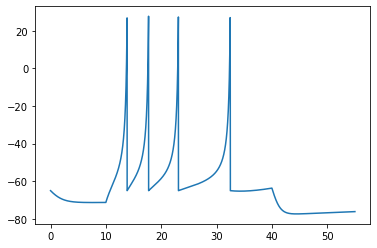

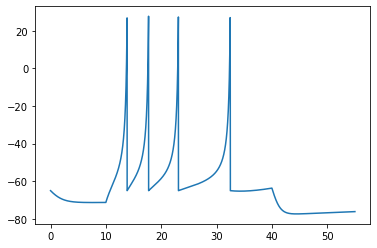

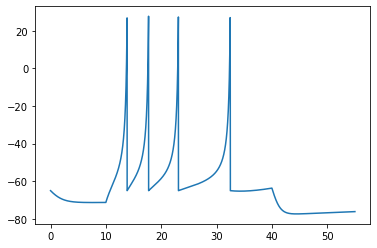

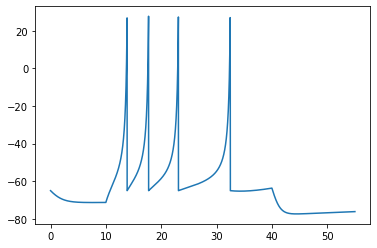

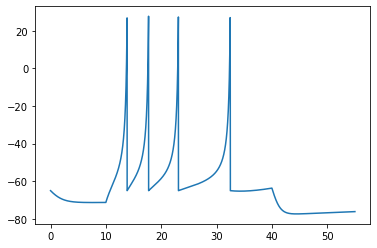

In [17]:

a = 0.02
b = 0.2
c = -65 
d = 2


def dv_dt(v, u, I):
    return 0.04*v**2 + 5*v + 140 - u + I
    
def du_dt(v, u):
    return a*(v*b-u)

def derivatives(vec, I):
    return np.array([dv_dt(vec[0], vec[1], I), du_dt(vec[0], vec[1])])

def I_input(t, start_I):
    if t > 10 and t < 40:
        return start_I
    return 0
    
# def izikevich_model(start_I):
#     v = -65
#     u = b*v
     
#     step = 0.01
#     t_start = 0
#     t_end = 50

#     time = np.arange(t_start, t_end, step)
#     v_vector = []


#     for dt in time:
#         I = I_input(dt, start_I)
#         dV = dv_dt(v,u,I)
#         dU = du_dt(v,u)

#         v = v + step*dV
#         u = u + step*dU

#         if v >= 30:
#             v = c
#             u += d
        
#         v_vector.append(v)
        
#     plt.plot(time, v_vector)
#     plt.show()
#     return v_vector

#at the starting point the system is balanced, so all the derivatives are zero
def izikevich_model(start_I):
    start = 0
    end = 55
    step = 0.01
    n = math.ceil((end-start)/step)
    t = np.linspace(start, end, n)
    listY = np.zeros([n, 2])
    vo = -65
    listY[0] = [-65, -13]
    for i in range(1, n):
        I = I_input(t[i], start_I)
        listY[i] = listY[i-1] + step*derivatives(listY[i-1], I)
        if listY[i][0] >= 30:
            listY[i][0] = c
            listY[i][1] += d
    plt.plot(t, listY.T[0])
    plt.show()
    return listY.T[0]
    
def layer(n):
    weights = np.ones([n]) # we define n ones
    outputs = []
    #start_I = random.randint(1, 30)
    start_I = 10
    for i in range(n):
        outputs.append(izikevich_model(start_I*weights[i]))
    
   # print(outputs)
   # return outputs
layer(5)  

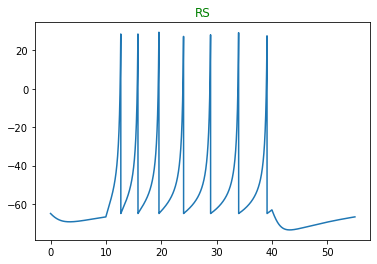

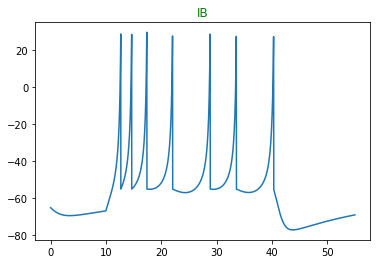

In [ ]:

a = 0.02
b = 0.2
c = -65 
d = 2

def dv_dt(v, u, I):
    return 0.04*v**2 + 5*v + 140 - u + I
    
def du_dt(v, u, a, b):
    return a*(v*b-u)

def derivatives(vec, I, a, b):
    return np.array([dv_dt(vec[0], vec[1], I), du_dt(vec[0], vec[1], a, b)])

def I_input(t, start_I):
    if t > 10 and t < 40:
        return start_I
    return 0
    

#at the starting point the system is balanced, so all the derivatives are zero
def izikevich_model(start_I, parameters, title):
    start = 0
    end = 55
    step = 0.01
    n = math.ceil((end-start)/step)
    t = np.linspace(start, end, n)
    listY = np.zeros([n, 2])
    vo = -65
    listY[0] = [-65, -13]
    for i in range(1, n):
        I = I_input(t[i], start_I)
        listY[i] = listY[i-1] + step*derivatives(listY[i-1], I, parameters[0], parameters[1])
        if listY[i][0] >= 30:
            listY[i][0] = parameters[2]
            listY[i][1] += parameters[3]
            
    plt.title(title, color='green')
    plt.plot(t, listY.T[0])
    plt.show()
    return listY.T[0]
    
def layer():
    n = 7
    weights = np.ones([n]) # we define n ones
    outputs = []
    #start_I = random.randint(1, 30)
    start_I = 10
    
    params = [
    [0.1,0.26, -65, 2], #Rezonator - RS
    [0.1,0.26, -55, 4], #IB
    [0.1,0.26, -50, 2], #chattering
    [0.02, 0.2,-65, 2], #Normal spiking
    [0.02, 0.2,-65, 8], #Regular Spiking
    [0.1, 0.2, -65, 2], #Fast Spiking
    [0.1, 0.25,-65, 2], #Low-threshold Spiking - LTS
    ]

    titles = ['RS', 'IB', 'CH', 'NORMAL', 'RS', 'FS', 'LTS']
    for i in range(n):
        
        #generating the parameters - a, b, c, d
        #a is recovery speed/large means fast recovery and small means slow recovery after the spike
        #b is sensitivity to voltage - the dependence between u and v -> small b means weak dependence
        #c - starting voltage like -65 mV
        #d - small d - neuron spike can fire up quickly /represents "tiredness" of the neuron
        
        outputs.append(izikevich_model(start_I*weights[i], params[i], titles[i]))
    
   # print(outputs)
   # return outputs
layer()  